# Portfolio Markov Regime Demo

This notebook shows the portfolio-specific workflow for the Markov regime model. A Hidden Markov Model consumes one observed time series, so for a portfolio we first convert asset returns and weights into a single portfolio return path.

In [2]:
from riskoptima import RiskOptima
print(RiskOptima.VERSION)

2.5.2


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from riskoptima.reporting import (
    build_markov_regime_report,
    plot_markov_regime_chart,
    plot_markov_regime_probabilities,
)

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Build a synthetic multi-asset portfolio

The asset universe uses common portfolio sleeves: equity, duration, gold, quality, and cash. The return data is deterministic and offline-safe so the notebook can run in CI or during interviews without market-data access.

In [5]:
rng = np.random.default_rng(2026)
dates = pd.bdate_range("2020-01-02", periods=900)

market_regime = np.r_[
    rng.normal(0.00045, 0.008, 260),
    rng.normal(-0.00120, 0.022, 180),
    rng.normal(0.00085, 0.010, 260),
    rng.normal(0.00010, 0.007, 200),
]

asset_returns = pd.DataFrame({
    "Equity": market_regime + rng.normal(0.00010, 0.0045, len(dates)),
    "Duration": rng.normal(0.00012, 0.0060, len(dates)) - 0.30 * market_regime,
    "Gold": rng.normal(0.00008, 0.0090, len(dates)) + 0.10 * market_regime,
    "Quality": 0.65 * market_regime + rng.normal(0.00018, 0.0055, len(dates)),
    "Cash": rng.normal(0.00004, 0.0003, len(dates)),
}, index=dates)

weights = pd.Series({
    "Equity": 0.50,
    "Duration": 0.20,
    "Gold": 0.10,
    "Quality": 0.15,
    "Cash": 0.05,
})

asset_returns.head(), weights

(              Equity  Duration      Gold   Quality      Cash
 2020-01-02  0.000396  0.009989 -0.014657 -0.006746 -0.000028
 2020-01-03 -0.006312 -0.001119 -0.004624 -0.008215  0.000385
 2020-01-06 -0.015843  0.009560  0.002771 -0.002848 -0.000228
 2020-01-07  0.013961 -0.005112  0.001540  0.005233 -0.000056
 2020-01-08  0.006869 -0.001154 -0.000589 -0.000153 -0.000098,
 Equity      0.50
 Duration    0.20
 Gold        0.10
 Quality     0.15
 Cash        0.05
 dtype: float64)

## 2. Convert asset returns to portfolio returns

This is the key step. The HMM does not receive the holdings table directly; it receives the realized portfolio return path created from the holdings and weights.

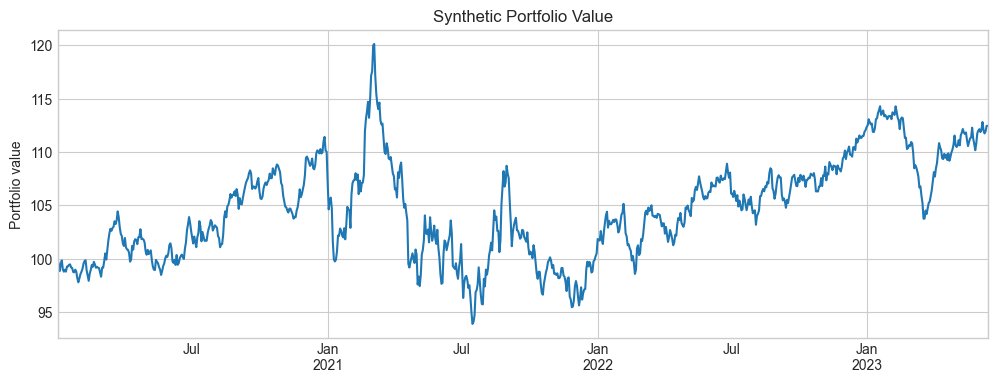

In [7]:
portfolio_returns = asset_returns.dot(weights).rename("portfolio_returns")
portfolio_value = (1.0 + portfolio_returns).cumprod() * 100.0

fig, ax = plt.subplots(figsize=(12, 4))
portfolio_value.plot(ax=ax, title="Synthetic Portfolio Value")
ax.set_ylabel("Portfolio value")
plt.show()

## 3. Fit the Markov regime report

We pass `portfolio_returns` with `input_type="returns"`. The report includes the transition matrix, regime probabilities, most likely state sequence, and regime summary statistics.

In [9]:
portfolio_report = build_markov_regime_report(
    portfolio_returns,
    input_type="returns",
    n_regimes=3,
    random_state=42,
    n_iter=100,
)

portfolio_report.metrics["transition_matrix"].round(3)

,Regime 0,Regime 1,Regime 2
Regime 0,0.633,0.023,0.344
Regime 1,0.002,0.998,0.000
Regime 2,0.129,0.000,0.871


## 4. Review regime statistics

The state summary helps label the regimes. For example, a low-mean/high-volatility state is usually interpreted as stress, while a high-mean/lower-volatility state can be interpreted as recovery or growth.

In [11]:
portfolio_report.metrics["regime_summary"].round(5)

,count,mean,std,min,max
regime,,,,,
0,30,-0.01618,0.01046,-0.03926,0.01311
1,719,0.00028,0.00571,-0.01830,0.02063
2,151,0.00284,0.01090,-0.01940,0.03780


## 5. Plot portfolio regimes

This chart colors the cumulative portfolio path by the most likely hidden state. It is the portfolio version of the market regime chart.

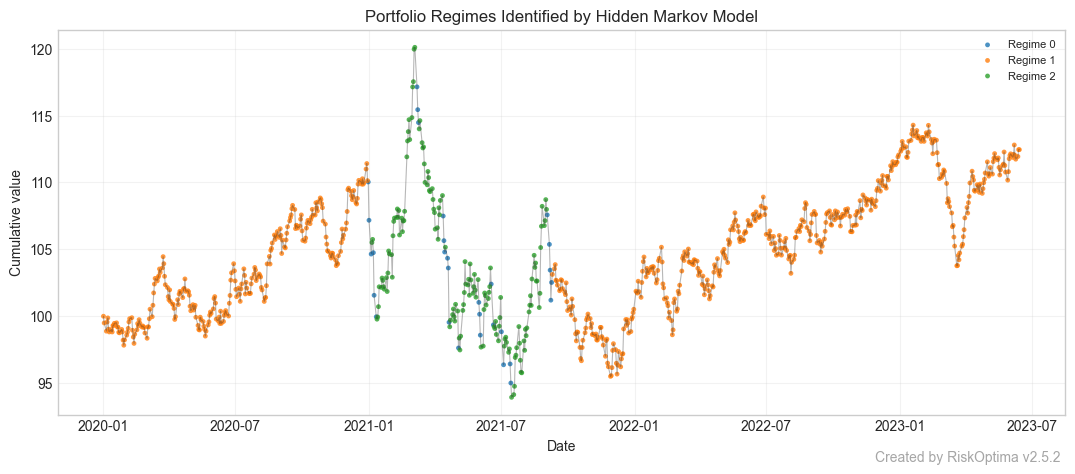

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
plot_markov_regime_chart(
    portfolio_report,
    title="Portfolio Regimes Identified by Hidden Markov Model",
    ax=ax,
)
plt.show()

## 6. Plot regime probabilities

The probability view is useful because regime changes are probabilistic. It is usually better to monitor regime probabilities than to treat state changes as perfectly certain switch points.

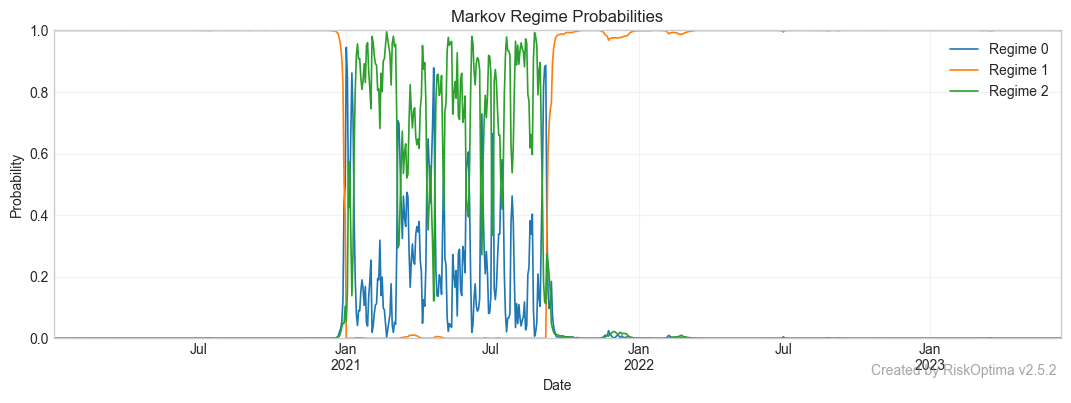

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
plot_markov_regime_probabilities(portfolio_report, ax=ax)
plt.show()